Files already downloaded and verified


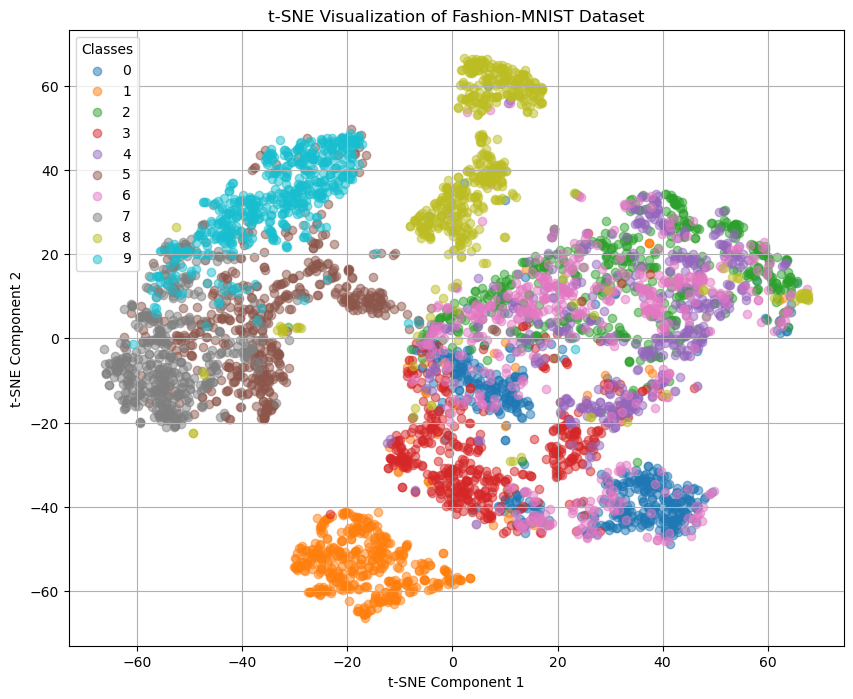

In [6]:
import torch
from torchvision.datasets import FashionMNIST, MNIST, CIFAR10
import torchvision.transforms as transforms
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# Transform function for CIFAR-10 dataset
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

fashion_mnist_train = FashionMNIST(root='.', train=True, transform=transforms.ToTensor(), download=True)
mnist_train = MNIST(root='.', train=True, transform=transforms.ToTensor(), download=True)
cifar10_train = CIFAR10(root='.', train=True, transform=transform, download=True)

def perform_tsne(dataset, name, input_size, isCIFAR=False):
    # Subsample data (reduce to 5000 samples for speed)
    num_samples = 5000  
    indices = np.random.choice(len(dataset.data), num_samples, replace=False)
    
    if isCIFAR:
        images = dataset.data[indices].astype(np.float32) / 255.0  # Normalize
        images = images.reshape((num_samples, input_size * input_size * 3))  # Flatten
    else:
        images = dataset.data.numpy()[indices].reshape((num_samples, input_size * input_size))

    labels = np.array(dataset.targets)[indices]  # Convert labels to NumPy and match subsample

    # Reduce dimensionality with t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, early_exaggeration=12, n_iter=1000)
    tsne_results = tsne.fit_transform(images)

    # Plot t-SNE results
    plt.figure(figsize=(10, 8))
    for i in range(10):  # Loop through each class
        indices = labels == i  # Ensure labels are NumPy array
        plt.scatter(tsne_results[indices, 0], tsne_results[indices, 1], label=str(i), alpha=0.5)
    
    plt.title(f't-SNE Visualization of {name} Dataset')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    plt.legend(title='Classes')
    plt.grid(True)
    plt.show()

perform_tsne(fashion_mnist_train, "Fashion-MNIST", 28, False)

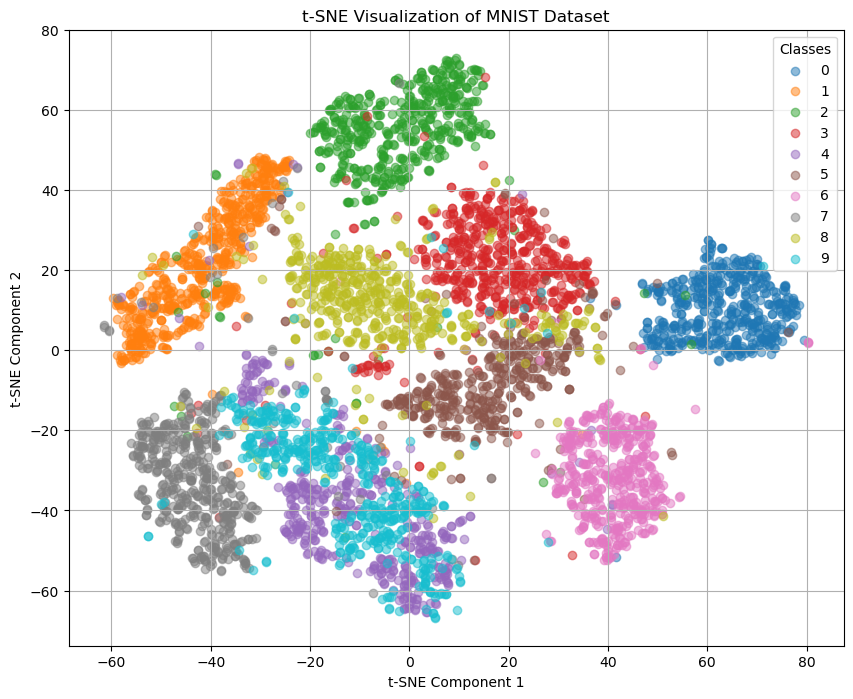

In [7]:
perform_tsne(mnist_train, "MNIST", 28, False)

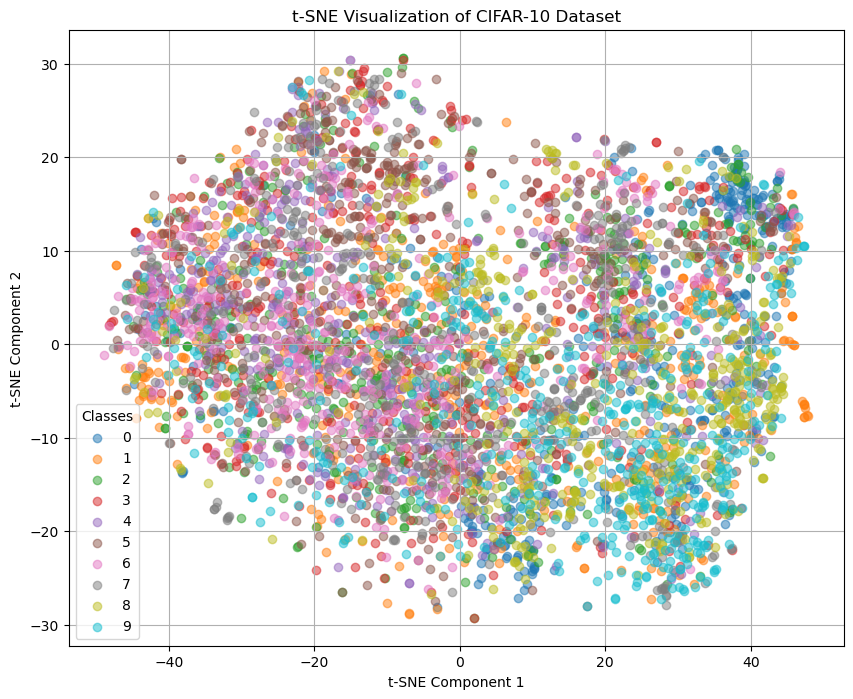

In [8]:
perform_tsne(cifar10_train, "CIFAR-10", 32, True)